# **Step 1: The Simulation Engine**

## **1.1. Lognormal Distribution**

In [ ]:
import numpy as np
import uuid
from datetime import datetime, timedelta

# 1) Base Class
class Transaction:
  def __init__(self, customer_id, *args, **kwargs):
    self.transaction_id = str(uuid.uuid4())
    self.customer_id = customer_id
    self.timestamp = kwargs.get('timestamp', datetime.now())

    self.location = kwargs.get('location', 'UNKNOWN')
    self.is_international = kwargs.get('is_international', False)

  def generate_amount(self):
    raise NotImplementedError("Subclassed must implement this method")

  def to_dict(self):
    return {
        "transaction_id": self.transaction_id,
        "customer_id": self.customer_id,
        "timestamp": self.timestamp.strftime("%Y-%m-%d %H:%M:%S"),
        "amount": self.generate_amount(),
        "location": self.location,
        "type": self.__class__.__name__
    }

# 2) Subclasses
class RetailSwipe(Transaction):
  def generate_amount(self):
    amount = np.random.lognormal(mean=3.5, sigma=1.0)
    return round(amount, 2)

class CorporateWire(Transaction):
  def generate_amount(self):
    amount = np.random.lognormal(mean=9.0, sigma=1.5)
    return round(amount, 2)

class ATMWithdrawal(Transaction):
  def generate_amount(self):
    amount = np.random.lognormal(mean=5.0, sigma=1.0)
    return int(round(amount//10)*10)

# 3) Testing
if __name__ == "__main__":
  retail_tx = RetailSwipe(customer_id="CUST-001", location="Baku", is_international=False)
  wire_tx = CorporateWire(customer_id="CORP-999", location="Baku", is_international=True)
  atm_tx = ATMWithdrawal(customer_id="ATM-555", location="Baku", is_international=False )

  print(f"Retail Transaction: {retail_tx.to_dict()}")
  print(f"Corporate Wire: {wire_tx.to_dict()}")
  print(f"ATM Withdrawal: {atm_tx.to_dict()}")

Retail Transaction: {'transaction_id': '587a013c-8fbc-4e6a-89bc-521888dd1e2c', 'customer_id': 'CUST-001', 'timestamp': '2026-04-01 11:47:21', 'amount': 10.95, 'location': 'Baku', 'type': 'RetailSwipe'}
Corporate Wire: {'transaction_id': '700b2c91-d823-48b4-a69c-64d6466dfc42', 'customer_id': 'CORP-999', 'timestamp': '2026-04-01 11:47:21', 'amount': 8067.58, 'location': 'Baku', 'type': 'CorporateWire'}
ATM Withdrawal: {'transaction_id': '4252f1bd-ef9c-42ef-bbe4-810029d13c7c', 'customer_id': 'ATM-555', 'timestamp': '2026-04-01 11:47:21', 'amount': 30, 'location': 'Baku', 'type': 'ATMWithdrawal'}


## **1.2. Async Simulation Engine**

In [ ]:
from google.colab import drive
import os
import numpy as np
import uuid
from datetime import datetime, timedelta
import asyncio
import pandas as pd
import time
import random

# 1) Base Class & Subclasses
class Transaction:
  def __init__(self, customer_id, *args, **kwargs):
    self.transaction_id = str(uuid.uuid4())
    self.customer_id = customer_id
    self.timestamp = kwargs.get('timestamp', datetime.now())
    self.location = kwargs.get('location', 'UNKNOWN')
    self.is_international = kwargs.get('is_international', False)

  def generate_amount(self):
    raise NotImplementedError("Subclassed must implement this method")

  def to_dict(self):
    return {
        "transaction_id": self.transaction_id,
        "customer_id": self.customer_id,
        "timestamp": self.timestamp.strftime("%Y-%m-%d %H:%M:%S"),
        "amount": self.generate_amount(),
        "location": self.location,
        "type": self.__class__.__name__
    }

class RetailSwipe(Transaction):
  def generate_amount(self):
    amount = np.random.lognormal(mean=3.5, sigma=1.0)
    return round(amount, 2)

class CorporateWire(Transaction):
  def generate_amount(self):
    amount = np.random.lognormal(mean=9.0, sigma=1.5)
    return round(amount, 2)

class ATMWithdrawal(Transaction):
  def generate_amount(self):
    amount = np.random.lognormal(mean=5.0, sigma=1.0)
    return int(round(amount//10)*10)

# 2) Asynchronous Generation Engine
async def process_transaction(transaction):
  """Simulates network latency"""
  network_latency = np.random.exponential(0.1)
  await asyncio.sleep(network_latency)
  return transaction.to_dict()

async def run_enterprise_simulation(num_transactions, time_tracker):
  print(f"Initializing simulation of {num_transactions:,} transactions...")

  tasks = []
  current_time = datetime.now()

  for i in range(num_transactions):
    valid_transaction = False

    while not valid_transaction:
        tx_type = np.random.choice(['Retail', 'Wire', 'ATM'], p=[0.75, 0.05, 0.20])

        # Customer Pools
        if tx_type == 'Retail':
          c_id = f"CUST-{np.random.randint(10000, 99999)}"
          tx_class = RetailSwipe
        elif tx_type == 'Wire':
          c_id = f"CORP-{np.random.randint(100, 999)}"
          tx_class = CorporateWire
        else:
          c_id = f"ATM-{np.random.randint(1000, 5000)}"
          tx_class = ATMWithdrawal

        if c_id not in time_tracker:
          start_offset = timedelta(days=np.random.randint(0, 1095))
          proposed_time = current_time - start_offset

          # Customer Types
          if tx_type == 'Retail':
            # 20% High, 60% Nomal, 20% Poor Spenders
            persona_gap = np.random.choice(
                [np.random.uniform(1, 3), np.random.uniform(4, 10), np.random.uniform(15, 30)],
                p=[0.2, 0.6, 0.2]
            )
          elif tx_type == 'Wire':
            persona_gap = np.random.uniform(1, 7)
          else:
            persona_gap = np.random.uniform(3, 14)

          time_tracker[c_id] = {'timestamp': proposed_time, 'persona_gap': persona_gap}
          valid_transaction = True

        else:
          # Human Burstiness
          last_time = time_tracker[c_id]['timestamp']
          persona_gap = time_tracker[c_id]['persona_gap']
          behavior_roll = random.random()

          if behavior_roll < 0.15:
            # 15% Chance: Shopping Moments
            time_gap = timedelta(hours=np.random.uniform(1, 8))
          elif behavior_roll < 0.2:
            # 5% Chance: Vacation Moments
            time_gap = timedelta(days=np.random.exponential(persona_gap * 4))
          else:
            # 80% Chance: Normal Daily Life
            time_gap = timedelta(days=np.random.exponential(persona_gap))

          proposed_time = last_time + time_gap

          # The Time Ceiling (Now)
          if proposed_time < current_time:
            time_tracker[c_id]['timestamp'] = proposed_time
            valid_transaction = True
          else:
            pass

    current_tx_time = time_tracker[c_id]['timestamp']
    tx = tx_class(customer_id=c_id, location="Baku", timestamp=current_tx_time)
    tasks.append(process_transaction(tx))

  completed_transactions = await asyncio.gather(*tasks)
  return completed_transactions

# 3) Testing & Saving the Data
if __name__ == "__main__":
  drive.mount("/content/drive", force_remount=True)
  folder_path = '/content/drive/MyDrive/Data Science Projects/Enterprise Banking Intelligence & Fraud Detection System/'
  os.makedirs(folder_path, exist_ok=True)
  file_name= 'enterprise_banking_data.csv'
  full_file_path = os.path.join(folder_path, file_name)

  test_time_tracker = {}

  print('Generating 15,000 test transactions. Please wait...')
  import nest_asyncio
  nest_asyncio.apply()

  loop = asyncio.get_event_loop()
  generated_data = loop.run_until_complete(run_enterprise_simulation(15000, test_time_tracker))

  df_transactions = pd.DataFrame(generated_data)

  print(f"\nDataSet Shape: {df_transactions.shape}")
  display(df_transactions.head())
  df_transactions.to_csv(full_file_path, index=False)
  print(f"\nData successfully routed and saved to:\n{full_file_path}")

Mounted at /content/drive
Generating 15,000 test transactions. Please wait...
Initializing simulation of 15,000 transactions...

DataSet Shape: (15000, 6)


,transaction_id,customer_id,timestamp,amount,location,type
0,ae934a0c-af94-46c5-931a-ea8e0f8346f2,CUST-17833,2025-07-09 11:47:41,8.77,Baku,RetailSwipe
1,2837323c-a5f2-4c96-acf3-84c67220f161,CUST-47012,2023-05-17 11:47:41,34.40,Baku,RetailSwipe
2,bac6eca7-f1d0-48be-a5bc-765e18e0fc8e,CUST-48927,2025-05-19 11:47:41,3.46,Baku,RetailSwipe
3,46528c6f-89b1-46da-9e5b-28f5a378afc9,ATM-4476,2023-04-05 11:47:41,490.00,Baku,ATMWithdrawal
4,5e6116e6-536b-451e-872f-77c69ed4660e,CUST-97829,2024-12-26 11:47:41,20.58,Baku,RetailSwipe



Data successfully routed and saved to:
/content/drive/MyDrive/Data Science Projects/Enterprise Banking Intelligence & Fraud Detection System/enterprise_banking_data.csv


## **1.3. Big Data Scaling & Memory Management**

In [ ]:
from google.colab import drive
import os
import gc

drive.mount('/content/drive/')
folder_path = '/content/drive/MyDrive/Data Science Projects/Enterprise Banking Intelligence & Fraud Detection System/'
file_name = 'enterprise_banking_big_data.csv'
full_file_path = os.path.join(folder_path, file_name)

# Batch Strategy
total_rows_needed = 5000000
chunk_size = 100000
total_batches = total_rows_needed // chunk_size

print(f"Initializing Big Data Pipeline: {total_rows_needed:,} total records.")
print(f"Strategy: {total_batches} batches of {chunk_size:,} records each.\n")

master_time_tracker = {}

# Chunking Loop
for batch in range(1, total_batches + 1):
  print(f"Processing Batch {batch}/{total_batches}...")

  generated_data = await run_enterprise_simulation(chunk_size, master_time_tracker)
  df_chunk = pd.DataFrame(generated_data)

  if batch == 1:
    df_chunk.to_csv(full_file_path, index=False, mode='w')
  else:
    df_chunk.to_csv(full_file_path, index=False, mode='a', header=False)

  del generated_data
  del df_chunk
  gc.collect()

  print(f"Batch {batch} successfully appended to Drive. RAM cleared.\n")

print(f"\nPipline Completed. {total_rows_needed:,} rows successfully secured in your Drive.")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Initializing Big Data Pipeline: 5,000,000 total records.
Strategy: 50 batches of 100,000 records each.

Processing Batch 1/50...
Initializing simulation of 100,000 transactions...
Batch 1 successfully appended to Drive. RAM cleared.

Processing Batch 2/50...
Initializing simulation of 100,000 transactions...
Batch 2 successfully appended to Drive. RAM cleared.

Processing Batch 3/50...
Initializing simulation of 100,000 transactions...
Batch 3 successfully appended to Drive. RAM cleared.

Processing Batch 4/50...
Initializing simulation of 100,000 transactions...
Batch 4 successfully appended to Drive. RAM cleared.

Processing Batch 5/50...
Initializing simulation of 100,000 transactions...
Batch 5 successfully appended to Drive. RAM cleared.

Processing Batch 6/50...
Initializing simulation of 100,000 transactions...
Batch 6 successfully appended to Drive.

# **Step 2: Big Data & Distributed Cloud Computing**

## **2.1. Spark Cluster**

In [1]:
!pip install pyspark

from google.colab import drive
from pyspark.sql import SparkSession
import os

print("Initializing the Apache Spark Cluster...")

# 1) Initializing PySpark Session
spark = SparkSession.builder \
  .appName("Enterprise Fraud Detection") \
  .master("local[*]") \
  .config("spark.driver.memory", "4g") \
  .getOrCreate()

print(f"Spark Version Active: {spark.version}")

# 2) Connection & Distributed Ingestion of Big Data
drive.mount('/content/drive/')
folder_path = '/content/drive/MyDrive/Data Science Projects/Enterprise Banking Intelligence & Fraud Detection System/'
file_name = 'enterprise_banking_big_data.csv'
full_file_path = os.path.join(folder_path, file_name)

print(f"\\nIngesting massive dataset from: {full_file_path}")
df_spark = spark.read.csv(full_file_path, header=True, inferSchema=True)

print("\\n--- Distributed DataFrame Schema")
df_spark.printSchema()

print(f"\\nTotal Rows loaded into Cluster: {df_spark.count():,}")

Initializing the Apache Spark Cluster...
Spark Version Active: 4.0.2
Mounted at /content/drive/
\nIngesting massive dataset from: /content/drive/MyDrive/Data Science Projects/Enterprise Banking Intelligence & Fraud Detection System/enterprise_banking_big_data.csv
\n--- Distributed DataFrame Schema
root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- amount: double (nullable = true)
 |-- location: string (nullable = true)
 |-- type: string (nullable = true)

\nTotal Rows loaded into Cluster: 5,000,000


##  **2.2. Advanced Feature Engineering & Temporal Logic**

In [2]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

print("Initializing Advanced Feature Engineering...")

user_window = Window.partitionBy("customer_id").orderBy("timestamp")

# 1) Getting Previous Timestamp
df_features = df_spark.withColumn(
    "prev_timestamp",
    F.lag("timestamp", 1).over(user_window)
)

# 2) Calculating the Velocity of Transactions
df_features = df_features.withColumn(
    "seconds_since_last_tx",
    F.to_timestamp(F.col("timestamp")).cast("long") - F.to_timestamp(F.col("prev_timestamp")).cast("long")
)

# 3) Filling Null Values for Very First Transactions
df_features = df_features.fillna({"seconds_since_last_tx": -1})

print("\n--- Fraud Features")
df_features.filter(F.col("customer_id") == "CUST-55555") \
           .select("transaction_id", "customer_id", "timestamp", "amount", "seconds_since_last_tx") \
           .show(truncate=False)

Initializing Advanced Feature Engineering...

--- Fraud Features
+------------------------------------+-----------+-------------------+------+---------------------+
|transaction_id                      |customer_id|timestamp          |amount|seconds_since_last_tx|
+------------------------------------+-----------+-------------------+------+---------------------+
|a011030d-88f7-4663-8527-3696092ae278|CUST-55555 |2023-11-15 11:47:48|5.38  |-1                   |
|249f1b07-cb2c-4332-ad4d-f9ee04410f68|CUST-55555 |2023-11-15 18:22:00|5.57  |23652                |
|2ce0412d-c9dd-4ed7-bae4-8895fa301b1b|CUST-55555 |2023-11-17 20:04:15|94.3  |178935               |
|8c548603-b09f-407e-8d4c-67a0e1b87aa0|CUST-55555 |2023-12-10 05:15:43|12.12 |1933888              |
|c456ce21-0488-41d9-a895-12c341562a27|CUST-55555 |2023-12-10 10:24:46|43.85 |18543                |
|c67f2e24-b81a-4a0f-a474-13cae8d62a2a|CUST-55555 |2023-12-11 16:23:33|36.72 |107927               |
|be79b81e-b773-450e-a6cd-d3a3b92165

## **2.3. Engineering the Rolling Spending Average & Deviation Ratio**

In [3]:
import glob
import shutil

print("Initalizing Rolling Average Calculations...")

# 1) Historical Bounded Window
history_window = Window.partitionBy('customer_id') \
                       .orderBy('timestamp') \
                       .rowsBetween(-60, -1)

# 2.1) Historical Average (for Normal Transactions)
df_features = df_features.withColumn(
    'historical_avg_amount',
    F.avg('amount').over(history_window)
)

# 2.2) Historical Average (for Very First Transactions)
df_features = df_features.withColumn(
    'historical_avg_amount',
    F.coalesce(F.col('historical_avg_amount'), F.col('amount'))
)

# 3) Fraud Multiplier
df_features = df_features.withColumn(
    'spend_multiplier',
    F.when(F.col('historical_avg_amount') == 0, 0.0) \
    .otherwise(F.round(F.col('amount') / F.col('historical_avg_amount'), 2))
)

df_features = df_features.withColumn(
    "risk_label",
    F.when(F.col('spend_multiplier') >= 10, "Fraud").otherwise("Legitimate")
)

print("\nSaving Enriched Gold Dataset to Google Drive. This may take a few minutes...")
temp_folder_path = os.path.join(folder_path, 'temp_spark_output')
final_file_path = os.path.join(folder_path, 'enterprise_banking_big_data_final.csv')

df_features.coalesce(1).write.csv(temp_folder_path, header=True, mode='overwrite')
part_file = glob.glob(os.path.join(temp_folder_path, 'part-*.csv'))[0]

if os.path.exists(final_file_path):
  os.remove(final_file_path)
shutil.move(part_file, final_file_path)

shutil.rmtree(temp_folder_path)
print(f"Final Version of Dataset Successfully at: {final_file_path}")

print("\n--- Spending Deviation Features")
df_features.filter(F.col('customer_id') == 'CUST-55555') \
           .select('transaction_id', 'timestamp', 'amount', 'historical_avg_amount', 'spend_multiplier', 'risk_label') \
           .show(truncate=False)

Initalizing Rolling Average Calculations...

Saving Enriched Gold Dataset to Google Drive. This may take a few minutes...
Final Version of Dataset Successfully at: /content/drive/MyDrive/Data Science Projects/Enterprise Banking Intelligence & Fraud Detection System/enterprise_banking_big_data_final.csv

--- Spending Deviation Features
+------------------------------------+-------------------+------+---------------------+----------------+----------+
|transaction_id                      |timestamp          |amount|historical_avg_amount|spend_multiplier|risk_label|
+------------------------------------+-------------------+------+---------------------+----------------+----------+
|a011030d-88f7-4663-8527-3696092ae278|2023-11-15 11:47:48|5.38  |5.38                 |1.0             |Legitimate|
|249f1b07-cb2c-4332-ad4d-f9ee04410f68|2023-11-15 18:22:00|5.57  |5.38                 |1.04            |Legitimate|
|2ce0412d-c9dd-4ed7-bae4-8895fa301b1b|2023-11-17 20:04:15|94.3  |5.475             

## **2.4. Visualising Dual-Axis Time Series Chart**

Extracting distibuted data for CUST-99555 to local memory...
Extraction completed. Visualising 52 transactions.


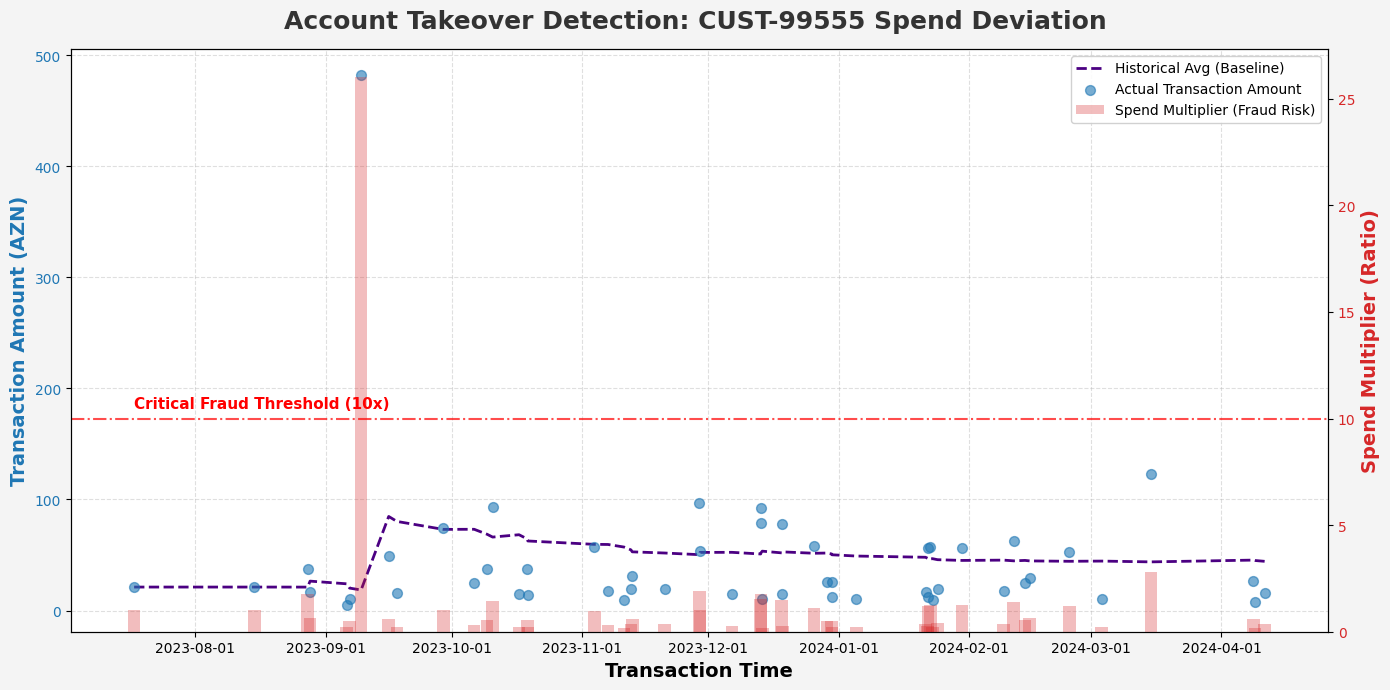

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# CUST-10000 -- CUST-99999
# CORP-100   -- CORP-999
# ATM-1000   -- ATM-5000

target_customer = 'CUST-99555'

print(f"Extracting distibuted data for {target_customer} to local memory...")

# 1) Big Data Extraction (Spark to Pandas)
pdf_cust = df_features.filter(F.col('customer_id') == target_customer) \
                      .orderBy('timestamp') \
                      .select('timestamp', 'amount', 'historical_avg_amount', 'spend_multiplier') \
                      .toPandas()

print(f"Extraction completed. Visualising {len(pdf_cust)} transactions.")

if len(pdf_cust) == 0:
  print(f"\n[Alert] No transactions found for '{target_customer}'")
  print("Please verify the Customer ID and try again. Plotting cancelled.")
else:
  pdf_cust['timestamp'] = pd.to_datetime(pdf_cust['timestamp'])
  pdf_cust['amount'] = pd.to_numeric(pdf_cust['amount'])
  pdf_cust['historical_avg_amount'] = pd.to_numeric(pdf_cust['historical_avg_amount'])
  pdf_cust['spend_multiplier'] = pd.to_numeric(pdf_cust['spend_multiplier'])

  pdf_cust = pdf_cust.sort_values('timestamp').reset_index(drop=True)

  fig, ax1 = plt.subplots(figsize=(14, 7), facecolor='#f4f4f4')
  fig.suptitle(f'Account Takeover Detection: {target_customer} Spend Deviation', fontsize=18, fontweight='bold', color='#333333')

  # 2.1) Visualising Left Axis: Financial Data (AZN)
  ax1.plot(pdf_cust['timestamp'], pdf_cust['historical_avg_amount'],
          color='indigo', linestyle='--', linewidth=2, label='Historical Avg (Baseline)')

  ax1.scatter(pdf_cust['timestamp'], pdf_cust['amount'],
              color='#1f77b4', s=50, alpha=0.6, zorder=5, label='Actual Transaction Amount')

  ax1.set_xlabel('Transaction Time', fontsize=14, fontweight='bold')
  ax1.set_ylabel('Transaction Amount (AZN)', fontsize=14, fontweight='bold', color='#1f77b4')
  ax1.tick_params(axis='y', labelcolor='#1f77b4')
  ax1.grid(True, linestyle='--', alpha=0.4)

  # 2.2) Visualising Right Axis: The Fraud Multiplier (Ratio)
  ax2 = ax1.twinx()
  ax2.bar(pdf_cust['timestamp'], pdf_cust['spend_multiplier'],
          width=3, color='#d62728', alpha=0.3, label='Spend Multiplier (Fraud Risk)')

  # Drawing a Danger Line
  ax2.axhline(y=10.0, color='red', linestyle='-.', linewidth=1.5, alpha=0.7)
  ax2.text(pdf_cust['timestamp'].iloc[0], 10.5, 'Critical Fraud Threshold (10x)', color='red', fontsize=11, fontweight='bold')

  ax2.set_ylabel('Spend Multiplier (Ratio)', fontsize=14, fontweight='bold', color='#d62728')
  ax2.tick_params(axis='y', labelcolor='#d62728')

  # 3) Formatting & Combining
  locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
  formatter = mdates.DateFormatter('%Y-%m-%d')
  ax1.xaxis.set_major_locator(locator)
  ax1.xaxis.set_major_formatter(formatter)
  plt.xticks(rotation=45)

  lines_1, labels_1 = ax1.get_legend_handles_labels()
  lines_2, labels_2 = ax2.get_legend_handles_labels()
  ax1.legend (lines_1 + lines_2, labels_1 + labels_2, loc='upper right', framealpha=0.9)

  plt.tight_layout()
  plt.show()